In [1]:
import zipfile

zip_path = "/content/Weather-Analysis-main (5).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [2]:
import os

print(os.listdir("/content"))

['.config', 'Weather-Analysis-main', 'Weather-Analysis-main (5).zip', 'sample_data']


In [3]:
import os

dataset_path = "/content/Weather-Analysis-main"

print(os.listdir(dataset_path))

['rain', 'cloud', 'weather_new_log.csv', '.DS_Store', 'README.md', 'sunrise', 'shine', 'pl_logo.png']


In [4]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
print(class_names)

Found 1123 files belonging to 4 classes.
Using 899 files for training.
Found 1123 files belonging to 4 classes.
Using 224 files for validation.
['cloud', 'rain', 'shine', 'sunrise']


In [5]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Rescaling

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained layers
base_model.trainable = False

model = Sequential([
    Rescaling(1./255, input_shape=(224,224,3)),
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(4, activation="softmax")
])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [7]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.7052 - loss: 0.7698 - val_accuracy: 0.8973 - val_loss: 0.3433
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.8966 - loss: 0.2792 - val_accuracy: 0.9107 - val_loss: 0.2463
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 27s 946ms/step - accuracy: 0.9366 - loss: 0.2042 - val_accuracy: 0.9241 - val_loss: 0.2268
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 27s 938ms/step - accuracy: 0.9522 - loss: 0.1557 - val_accuracy: 0.9062 - val_loss: 0.2272
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 40s 894ms/step - accuracy: 0.9444 - loss: 0.1542 - val_accuracy: 0.9241 - val_loss: 0.2099
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 41s 908ms/step - accuracy: 0.9722 - loss: 0.1059 - val_accuracy: 0.9286 - val_loss: 0.1865
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 27s 922ms/step - accuracy: 0.9666 - loss: 0.0920 - val_accuracy: 0.9330 - val_loss: 0.1819
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9800 - loss: 0.0857 - val_accuracy: 0.9

In [8]:
model.save("weather_mobilenet_model.keras")
print("Model Saved Successfully!")

Model Saved Successfully!


In [9]:
from google.colab import files
files.download("weather_mobilenet_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
loss, accuracy = model.evaluate(val_dataset)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy*100)

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 694ms/step - accuracy: 0.9241 - loss: 0.2140
Validation Loss: 0.21398122608661652
Validation Accuracy: 92.41071343421936


In [12]:
from google.colab import files

uploaded = files.upload()

Saving cloud_0.jpeg to cloud_0.jpeg


In [21]:
print(class_names)

['cloud', 'rain', 'shine', 'sunrise']


In [22]:
print(prediction)

[[0.00475788 0.92081267 0.05860662 0.01582278]]


In [24]:
from tensorflow.keras.models import load_model

model = load_model("/content/weather_mobilenet_model.keras")

print("Model loaded successfully!")

Model loaded successfully!


In [29]:
print(class_names)
print(prediction)
print(np.argmax(prediction))

['cloud', 'rain', 'shine', 'sunrise']
[[0.00476254 0.9185351  0.06079881 0.01590354]]
1


True: rain ---> Predicted: rain


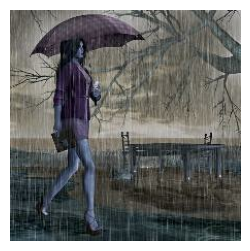

True: rain ---> Predicted: rain


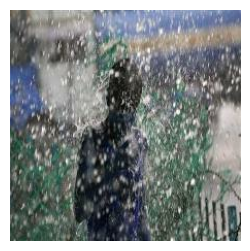

True: cloud ---> Predicted: cloud


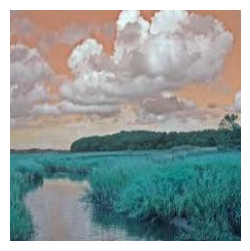

True: cloud ---> Predicted: cloud


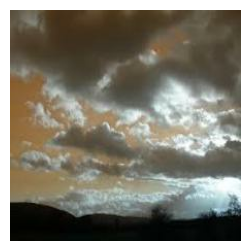

True: sunrise ---> Predicted: sunrise


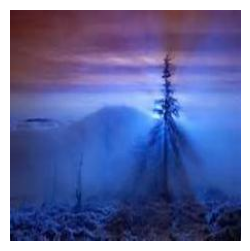

In [31]:
import matplotlib.pyplot as plt
import numpy as np

class_names = train_dataset.class_names

for images, labels in val_dataset.take(1):

    predictions = model.predict(images, verbose=0)

    for i in range(5):
        plt.figure(figsize=(3,3))
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")

        true_label = class_names[labels[i]]
        pred_label = class_names[np.argmax(predictions[i])]

        print(f"True: {true_label} ---> Predicted: {pred_label}")
        plt.show()

Saving cloud_0.jpeg to cloud_0 (3).jpeg


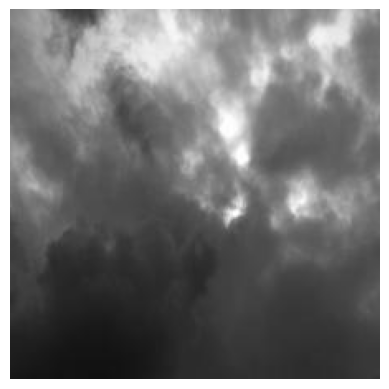

Prediction probabilities: [[9.9967909e-01 8.5729167e-05 1.2045351e-04 1.1477258e-04]]
Predicted Class: cloud
Confidence: 99.96791


In [32]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

img_path = list(uploaded.keys())[0]

# Load image
img = load_img(img_path, target_size=(224,224))

# Display image
plt.imshow(img)
plt.axis("off")
plt.show()

# Convert to array
img_array = img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# ⚠️ IMPORTANT:
# Since your model already has a Rescaling layer,
# DO NOT divide by 255 here.

prediction = model.predict(img_array, verbose=0)

class_names = train_dataset.class_names

print("Prediction probabilities:", prediction)

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Class:", predicted_class)
print("Confidence:", np.max(prediction) * 100)

Saving shine_0.jpeg to shine_0 (1).jpeg


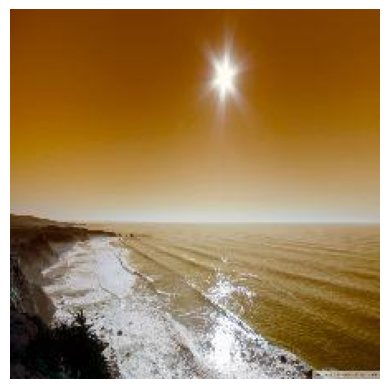

Prediction probabilities: [[1.3772584e-03 1.5049904e-05 9.6718007e-01 3.1427659e-02]]
Predicted Class: shine
Confidence: 96.71801


In [33]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

img_path = list(uploaded.keys())[0]

# Load image
img = load_img(img_path, target_size=(224,224))

# Display image
plt.imshow(img)
plt.axis("off")
plt.show()

# Convert to array
img_array = img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# ⚠️ IMPORTANT:
# Since your model already has a Rescaling layer,
# DO NOT divide by 255 here.

prediction = model.predict(img_array, verbose=0)

class_names = train_dataset.class_names

print("Prediction probabilities:", prediction)

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Class:", predicted_class)
print("Confidence:", np.max(prediction) * 100)

Saving rain_0.jpeg to rain_0 (1).jpeg


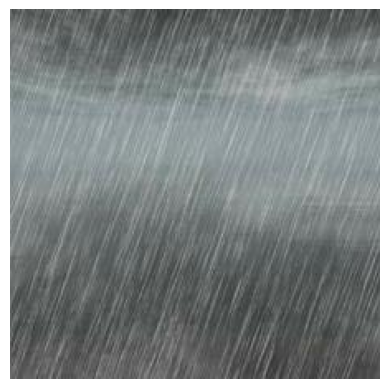

Prediction probabilities: [[4.8241418e-05 9.9987924e-01 2.4563291e-05 4.7907928e-05]]
Predicted Class: rain
Confidence: 99.98792


In [34]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

img_path = list(uploaded.keys())[0]

# Load image
img = load_img(img_path, target_size=(224,224))

# Display image
plt.imshow(img)
plt.axis("off")
plt.show()

# Convert to array
img_array = img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# ⚠️ IMPORTANT:
# Since your model already has a Rescaling layer,
# DO NOT divide by 255 here.

prediction = model.predict(img_array, verbose=0)

class_names = train_dataset.class_names

print("Prediction probabilities:", prediction)

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Class:", predicted_class)
print("Confidence:", np.max(prediction) * 100)

Saving sunrise_0.jpeg to sunrise_0 (2).jpeg


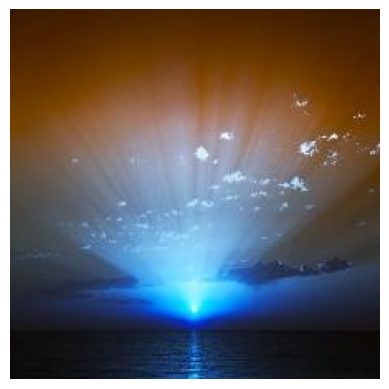

Prediction probabilities: [[2.5523799e-05 1.4066057e-06 3.3446337e-04 9.9963856e-01]]
Predicted Class: sunrise
Confidence: 99.96385


In [35]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

img_path = list(uploaded.keys())[0]

# Load image
img = load_img(img_path, target_size=(224,224))

# Display image
plt.imshow(img)
plt.axis("off")
plt.show()

# Convert to array
img_array = img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# ⚠️ IMPORTANT:
# Since your model already has a Rescaling layer,
# DO NOT divide by 255 here.

prediction = model.predict(img_array, verbose=0)

class_names = train_dataset.class_names

print("Prediction probabilities:", prediction)

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Class:", predicted_class)
print("Confidence:", np.max(prediction) * 100)